In [2]:
# import libraries for eda:

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# upload csv data:

df = pd.read_csv("kickstarter_projects.csv")
 
print(f'Shape: {df.shape}')
print(f'Duplikate: {df.duplicated().sum()}')

df.head()





Shape: (374853, 11)
Duplikate: 0


,ID,Name,Category,Subcategory,Country,Launched,Deadline,Goal,Pledged,Backers,State
0,1860890148,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,625,30,Failed
1,709707365,CRYSTAL ANTLERS UNTITLED MOVIE,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,22,3,Failed
2,1703704063,drawing for dollars,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,35,3,Successful
3,727286,Offline Wikipedia iPhone app,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,145,25,Successful
4,1622952265,Pantshirts,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,387,10,Failed


In [3]:
df.info()   

<class 'pandas.DataFrame'>
RangeIndex: 374853 entries, 0 to 374852
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   ID           374853 non-null  int64
 1   Name         374853 non-null  str  
 2   Category     374853 non-null  str  
 3   Subcategory  374853 non-null  str  
 4   Country      374853 non-null  str  
 5   Launched     374853 non-null  str  
 6   Deadline     374853 non-null  str  
 7   Goal         374853 non-null  int64
 8   Pledged      374853 non-null  int64
 9   Backers      374853 non-null  int64
 10  State        374853 non-null  str  
dtypes: int64(4), str(7)
memory usage: 31.5 MB


In [4]:
df.describe()

,ID,Goal,Pledged,Backers
count,3.748530e+05,3.748530e+05,3.748530e+05,374853.000000
mean,1.074656e+09,4.586378e+04,9.121073e+03,106.690359
std,6.191377e+08,1.158778e+06,9.132054e+04,911.718520
min,5.971000e+03,0.000000e+00,0.000000e+00,0.000000
25%,5.380728e+08,2.000000e+03,3.100000e+01,2.000000
50%,1.075300e+09,5.500000e+03,6.250000e+02,12.000000
75%,1.610149e+09,1.600000e+04,4.051000e+03,57.000000
max,2.147476e+09,1.663614e+08,2.033899e+07,219382.000000


In [5]:
df['Goal'].describe().apply(lambda x: f'{x:,.0f}')

count        374,853
mean          45,864
std        1,158,778
min                0
25%            2,000
50%            5,500
75%           16,000
max      166,361,391
Name: Goal, dtype: str

In [6]:
goal_min = df["Goal"].min()
goal_max = df["Goal"].max()

print(f"Min Goal: {goal_min}")
print(f"Max Goal: {goal_max}")

Min Goal: 0
Max Goal: 166361391


In [7]:
print((df['Goal'] == 0).sum())
print((df['Goal'] > 1000000).sum())

4
1083


<Axes: >

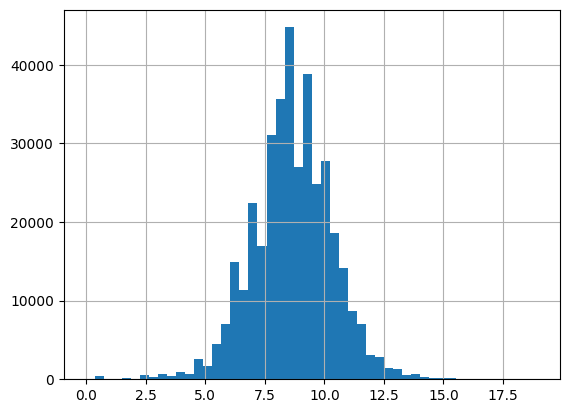

In [5]:
#df['Goal'].hist(bins=50)
df['Goal'].apply(np.log1p).hist(bins=50)

Data set reveals massive outlierr in the Goal column with values of > 100 million. This is likely an error, as it is highly improbable for a Kickstarter campaign to have such a high funding goal. Additionally, there are 4 entries with a Goal of 0, which may also be errors or indicate incomplete data. These outliers can significantly skew the analysis and should be investigated further to determine their validity and potential impact on the results.

In [9]:
# values bigger than quantile 99%:
goal_99 = df['Goal'].quantile(0.99)
print(f"99% quantile: {goal_99}")

99% quantile: 346282.9199999911


In [10]:
# content of column state:
print(df['State'].value_counts())

State
Failed        197611
Successful    133851
Canceled       38751
Live            2798
Suspended       1842
Name: count, dtype: int64


In [11]:
df['Category'].value_counts()

Category
Film & Video    62694
Music           49529
Publishing      39378
Games           35225
Technology      32562
Design          30065
Art             28151
Food            24599
Fashion         22812
Theater         10911
Comics          10819
Photography     10778
Crafts           8809
Journalism       4754
Dance            3767
Name: count, dtype: int64

In [12]:
df['Subcategory'].value_counts()

Subcategory
Product Design     22310
Documentary        16138
Tabletop Games     14178
Music              13339
Shorts             12357
                   ...  
Residencies           69
Letterpress           49
Chiptune              35
Literary Spaces       27
Taxidermy             13
Name: count, Length: 159, dtype: int64

In [13]:
df['Country'].value_counts()

Country
United States     292618
United Kingdom     33671
Canada             14756
Australia           7839
Germany             4171
France              2939
Italy               2878
Netherlands         2868
Spain               2276
Sweden              1757
Mexico              1752
New Zealand         1447
Denmark             1113
Ireland              811
Switzerland          760
Norway               708
Hong Kong            618
Belgium              617
Austria              597
Singapore            555
Luxembourg            62
Japan                 40
Name: count, dtype: int64

In [14]:
df.isnull().sum()

ID             0
Name           0
Category       0
Subcategory    0
Country        0
Launched       0
Deadline       0
Goal           0
Pledged        0
Backers        0
State          0
dtype: int64

In [15]:
# deleted Canceled, Suspended and Live + Imbalace check:
df = df[df['State'].isin(['Successful', 'Failed'])]
df['State'].value_counts(normalize=True)

State
Failed        0.59618
Successful    0.40382
Name: proportion, dtype: float64

<Axes: xlabel='State', ylabel='Goal'>

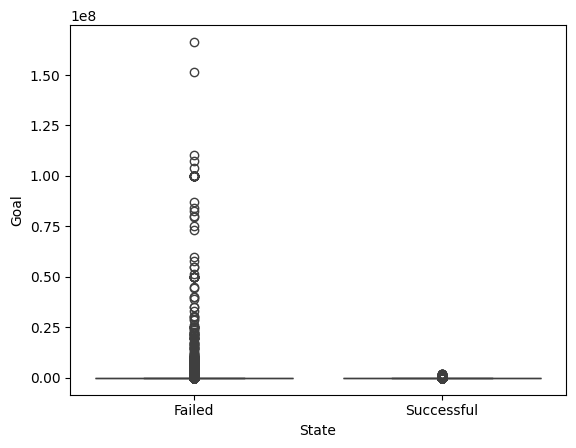

In [16]:
sns.boxplot(x='State', y='Goal', data=df)

<Axes: xlabel='State', ylabel='Goal'>

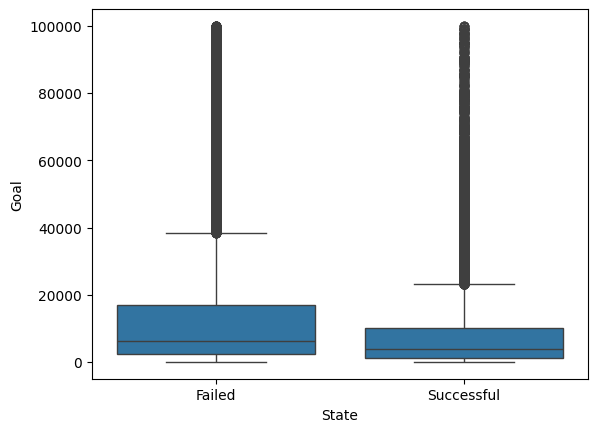

In [17]:
sns.boxplot(x='State', y='Goal', data=df[df['Goal'] < 100_000])

- Failed:     Median ~7.000€,  Box bis ~18.000€
- Successful: Median ~5.000€,  Box bis ~9.000€

Projects with smaller goals tend to have a higher success rate.

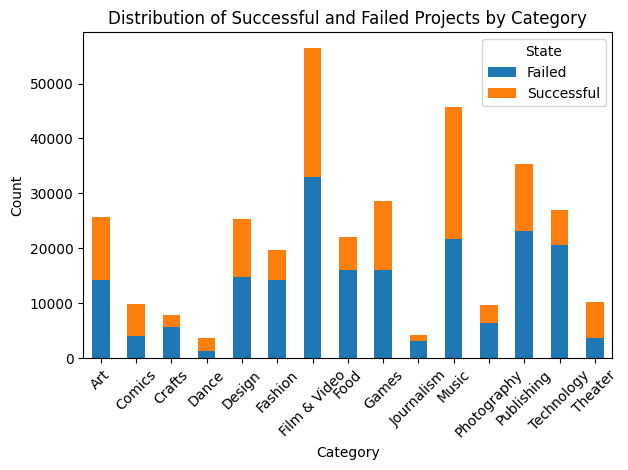

In [18]:
df.groupby('Category')['State'].value_counts()

plot_data = df.groupby('Category')['State'].value_counts().unstack()
plot_data.plot(kind='bar', stacked=True)
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Distribution of Successful and Failed Projects by Category')
plt.legend(title='State')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Failed:     Median ~35 days
- Successful: Median ~30 days

Sucessfull projects tend to have a shorter duration than failed ones, suggesting that longer campaigns may struggle to maintain momentum and interest over time.

<Axes: xlabel='State', ylabel='Duration'>

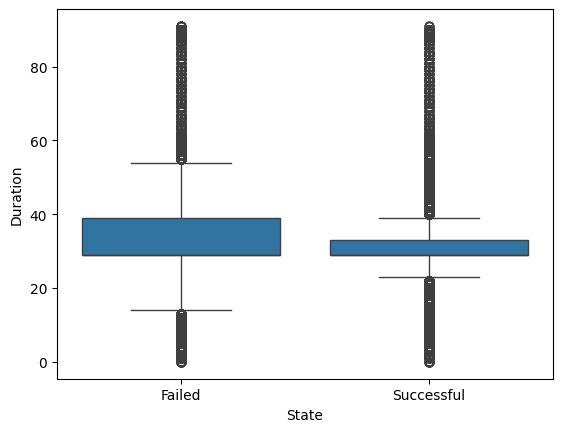

In [19]:
# date feature:

df['Launched'] = pd.to_datetime(df['Launched'])
df['Deadline'] = pd.to_datetime(df['Deadline'])
df['Duration'] = (df['Deadline'] - df['Launched']).dt.days
sns.boxplot(x='State', y='Duration', data=df)


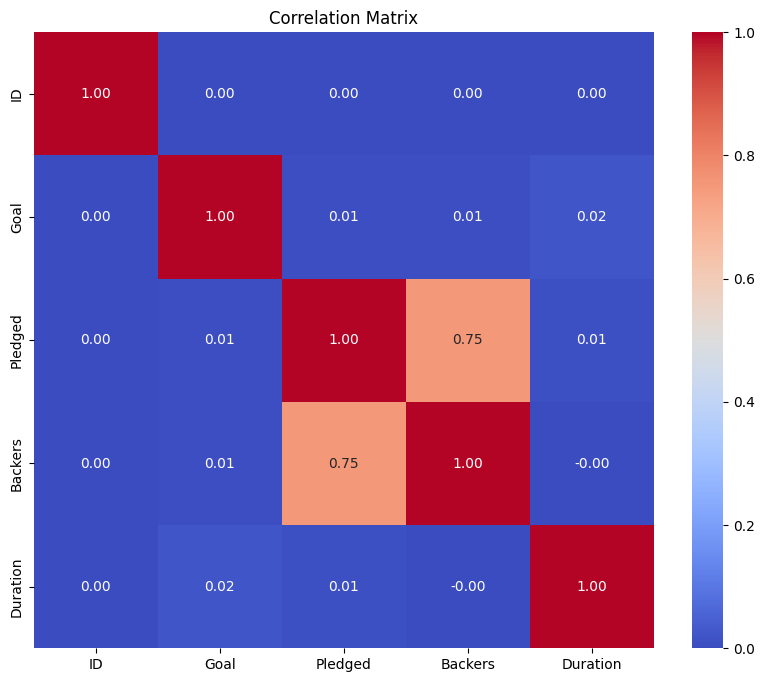

In [20]:
# correlation matrix:
numeric_cols = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_cols.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

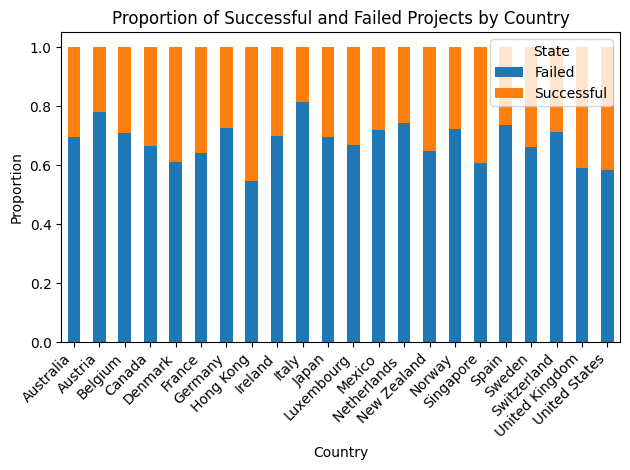

In [22]:
# successrate by country:
country_success = df.groupby('Country')['State'].value_counts(normalize=True).unstack()
country_success.plot(kind='bar', stacked=True)
plt.xlabel('Country')
plt.ylabel('Proportion')
plt.title('Proportion of Successful and Failed Projects by Country')
plt.legend(title='State')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [25]:
df['Country'].value_counts()

Country
United States     261358
United Kingdom     29453
Canada             12370
Australia           6616
Germany             3436
France              2520
Netherlands         2411
Italy               2369
Spain               1873
Sweden              1509
Mexico              1411
New Zealand         1274
Denmark              926
Ireland              683
Switzerland          652
Norway               582
Belgium              523
Austria              485
Hong Kong            477
Singapore            454
Luxembourg            57
Japan                 23
Name: count, dtype: int64

### Interpretation: Proportion of Successful and Failed Projects by Country

The chart shows the proportion of successful and failed projects per country. In combination with the absolute project counts, this gives a more complete picture of country-level performance.

#### Countries with relatively high success rates
- **United States** and **United Kingdom** stand out as the **most active countries by far** in terms of project volume, and both show **comparatively strong success rates (~42% and ~41% respectively)**.
- **Hong Kong** achieves the **highest success rate (~45%)** among all countries, though with fewer total projects.
- **Singapore** and **Denmark** also perform above average with success rates around **39%**.

#### Countries with relatively low success rates
- **Italy** has the **lowest success rate (~19%)**, meaning roughly 4 out of 5 projects fail.
- **Austria**, **Netherlands**, and **Spain** also show high failure rates, each with success rates **below 28%**.
- **Mexico**, **Norway**, and **Germany** similarly struggle, with success rates around **27–28%**.

#### Volume vs. success rate
- The vast majority of projects originate from the **United States**, followed distantly by the **United Kingdom** and **Canada**. Most other countries contribute only a small fraction of total projects.
- This means that **country-level patterns outside the US and UK should be interpreted cautiously**, as smaller sample sizes can lead to less reliable proportions.

#### Overall insight
Country appears to be a **relevant feature** for predicting project success. Projects from **English-speaking countries** (US, UK) tend to have better outcomes, potentially due to **larger audiences, stronger Kickstarter communities, and more experience with crowdfunding**. Non-English-speaking European countries generally show **higher failure rates**, which may reflect cultural, linguistic, or market access barriers.

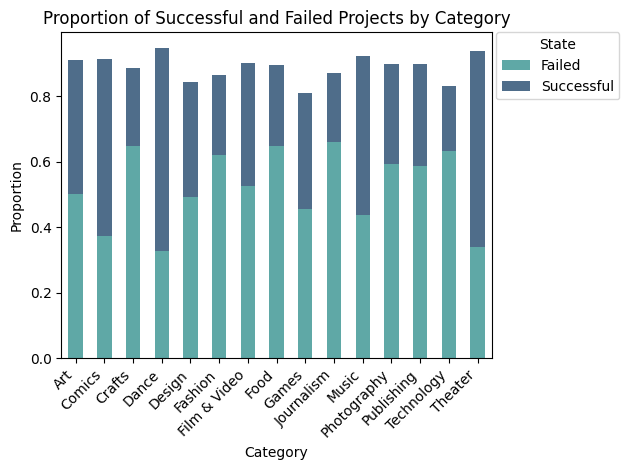

In [8]:
# category_success = df.groupby('Category')['State'].value_counts(normalize=True).unstack()
# category_success.plot(kind='bar', stacked=True)
# plt.xlabel('Category')
# plt.ylabel('Proportion')
# plt.title('Proportion of Successful and Failed Projects by Category')
# plt.legend(title='State')
# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()
# plt.show()

color_map = {"Failed": "#5FA8A6", "Successful": "#4F6D8A"}

category_success = df.groupby('Category')['State'].value_counts(normalize=True).unstack()[['Failed', 'Successful']]
category_success.plot(kind='bar', stacked=True, color=[color_map[col] for col in category_success.columns])
plt.xlabel('Category')
plt.ylabel('Proportion')
plt.title('Proportion of Successful and Failed Projects by Category')
plt.legend(title='State', bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Interpretation: Proportion of Successful and Failed Projects by Category

The chart shows that **failure rates are higher than success rates in most categories**. Only a few categories have a larger share of successful projects than failed ones.

#### Categories with relatively high success rates
- **Dance** has the highest success proportion, with about **65% successful** projects.
- **Theater** also performs strongly, with around **64% successful** projects.
- **Comics** shows a solid success rate at roughly **59%**.
- **Music** is one of the few large categories where **successful projects slightly outnumber failed ones**.

#### Categories with relatively low success rates
- **Technology** has the lowest success rate, with only about **24% successful** projects.
- **Journalism**, **Food**, **Crafts**, and **Fashion** also have high failure proportions.
- These categories may face stronger competition, higher funding goals, or greater difficulty delivering tangible outcomes.

#### Mid-range categories
- **Art, Games, Design, Film & Video, Publishing,** and **Photography** fall in the middle, but still have **more failed than successful** projects overall.

#### Overall insight
Project success appears to depend strongly on **category**. Creative and performance-based categories such as **Dance, Theater, Comics, and Music** tend to have better outcomes, while categories such as **Technology** and **Journalism** seem riskier. This suggests that **category is likely an important predictive feature** for project success.

In [27]:
# Top 10 und Flop 10 Subcategories
success_rate = df.groupby('Subcategory')['State'].apply(
    lambda x: (x == 'Successful').mean()
).sort_values()

print("Flop 10:")
print(success_rate.head(10))
print("\nTop 10:")
print(success_rate.tail(10))

Flop 10:
Subcategory
Apps            0.071496
Web             0.102808
Mobile Games    0.106029
Video           0.132468
Food Trucks     0.137865
Software        0.144190
Candles         0.145503
Action          0.172303
Hip-Hop         0.174039
Television      0.179931
Name: State, dtype: float64

Top 10:
Subcategory
Country & Folk     0.667458
Tabletop Games     0.669789
Letterpress        0.673913
Classical Music    0.675000
Indie Rock         0.678927
Literary Spaces    0.684211
Dance              0.695221
Anthologies        0.706920
Residencies        0.735294
Chiptune           0.818182
Name: State, dtype: float64


Flops:
- Apps:        7%   ← almost no one funds apps on Kickstarter
- Web:         10%  ← same
- Mobile Games: 11% ← too much competition, too high expectations

Tops:
- Chiptune:      82%  ← very small but loyal community
- Residencies:   74%  ← artistic niche projects
- Tabletop Games: 67% ← large engaged community

In [29]:
success_rate = df.groupby('Subcategory')['State'].apply(
    lambda x: (x == 'Successful').mean()
)
count = df.groupby('Subcategory')['State'].count()

summary = pd.DataFrame({'success_rate': success_rate, 'count': count})
summary.sort_values('success_rate', ascending=False).head(10)


,success_rate,count
Subcategory,,
Chiptune,0.818182,33
Residencies,0.735294,68
Anthologies,0.706920,737
Dance,0.695221,2218
Literary Spaces,0.684211,19
Indie Rock,0.678927,5329
Classical Music,0.675000,2440
Letterpress,0.673913,46
Tabletop Games,0.669789,11744
